# 08 SpaceX Falcon 9 - Machine Learning Modeling

This notebook is **Step 08** in a multi-step end-to-end data science project that analyzes and predicts **first-stage landing success** for SpaceX Falcon 9 launches.

In this step we:
- train a few baseline classification models to predict landing success (`Class`)
- tune hyperparameters with cross-validated grid search
- evaluate tuned models on a held-out test split and export a compact performance summary

**Pipeline overview:**

- **Step 01:** Collect launch data from the SpaceX REST API and create an initial modeling dataset.
- **Step 02:** Scrape a *fixed Wikipedia revision* of Falcon 9 & Falcon Heavy launch tables and export a clean CSV for supplementary analysis.
- **Step 03:** Clean and engineer features, create the landing success label (`Class`) and export the modeling dataset.
- **Step 04:** Load the labeled dataset into SQLite and explore patterns with SQL.
- **Step 05:** Visual EDA + one-hot encoding for modeling.
- **Step 06:** Interactive map + proximity distances (Folium).
- **Step 07:** Dashboarding (Dash) for interactive exploration.
- **Step 08 (this notebook):** Train + tune models and compare performance.


**Inputs:**

- `../data/processed/03_dataset_part_2.csv` (labeled launch records including the target `Class`)
- `../data/processed/05_dataset_part_3.csv` (one-hot encoded feature matrix)

**Primary outputs:**

- `../data/processed/08_model_performance.csv` (test accuracy, CV score, best params)
- `../data/processed/08_best_model.json` (selected best model + params)
- `../data/processed/08_best_model.joblib` (serialized fitted pipeline)
- `../data/processed/08_feature_names.json` (feature names expected by the pipeline)

## Notebook sections

1. **Setup**
2. **Load prepared datasets**
3. **Prepare features and target**
4. **Model training + hyperparameter tuning**
5. **Model comparison**
6. **Export artifacts**
7. **Assumptions**

---

## 1. Setup

In [1]:
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Paths
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents = True, exist_ok = True)

DATASET_PART_2 = PROCESSED_DIR / '03_dataset_part_2.csv'
DATASET_PART_3 = PROCESSED_DIR / '05_dataset_part_3.csv'

# Artifacts
MODEL_PERF_OUT = PROCESSED_DIR / '08_model_performance.csv'
BEST_MODEL_OUT = PROCESSED_DIR / '08_best_model.json'

In [2]:
# Helper: confusion matrix plot
def plot_confusion_matrix(y, y_predict):
    'This function plots the confusion matrix'
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax = plt.subplot()
    sns.heatmap(cm, annot = True, ax = ax); #annot = True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'landed']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show()

## 2. Load prepared datasets

We load the labeled dataset from **Step 03** (contains `Class`) and the one-hot encoded feature matrix from **Step 05** (numeric features only).

In [3]:
# Load engineered launch records
data = pd.read_csv(DATASET_PART_2)

data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [4]:
print('dataset_part_2 shape:', data.shape)
print('Class distribution:', data['Class'].value_counts().to_dict())

dataset_part_2 shape: (90, 18)
Class distribution: {1: 60, 0: 30}


In [5]:
# Load one-hot encoded feature matrix
X = pd.read_csv(DATASET_PART_3)

X.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6123.547647,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
print('dataset_part_3 shape:', X.shape)

dataset_part_3 shape: (90, 80)


## 3. Prepare target and features

- `Y`: target vector (`Class` = 1 successful landing, 0 otherwise)
- `X`: one-hot encoded feature matrix

We standardize features before modeling to keep the setup comparable across model families and to support distance-based methods like kNN and margin-based methods like SVM.

In [7]:
Y = data['Class'].to_numpy()

In [8]:
# Split into train/test sets (80/20) using a fixed random seed for reproducibility.
# Note: scaling is applied inside model pipelines during cross-validation (fit per fold).

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size = 0.2,
    random_state = 2,
    stratify = Y
)

In [9]:
print('Train samples:', Y_train.shape, '| Test samples:', Y_test.shape)

Train samples: (72,) | Test samples: (18,)


## 4. Model training with hyperparameter search
Each model family is tuned with a small grid search using **10-fold cross validation** on the training split, then evaluated on the held-out test split.

### 4.1 Logistic Regression

Grid search over a small `C` range (L2 penalty).

In [10]:
# Pipeline: scale within CV folds + logistic regression
logreg_pipe = Pipeline([
    ('scaler', preprocessing.StandardScaler()),
    ('model', LogisticRegression(max_iter = 1000))
])

parameters = {
    'model__C': [0.01, 0.1, 1],
    'model__solver': ['lbfgs'] 
} # penalty l2 is default

logreg_cv = GridSearchCV(logreg_pipe, parameters, cv = 10)
logreg_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >

In [11]:
# Best hyperparameters and cross-validated training score (mean CV accuracy)
print('Tuned hyperparameters (best parameters): ', logreg_cv.best_params_)
print('Accuracy: ', logreg_cv.best_score_)

Tuned hyperparameters (best parameters):  {'model__C': 1, 'model__solver': 'lbfgs'}
Accuracy:  0.8517857142857144


In [12]:
# Evaluate logistic regression on the held-out test split
logreg_accuracy = logreg_cv.score(X_test, Y_test)
print('Accuracy on test data: ', logreg_accuracy)

Accuracy on test data:  0.7777777777777778


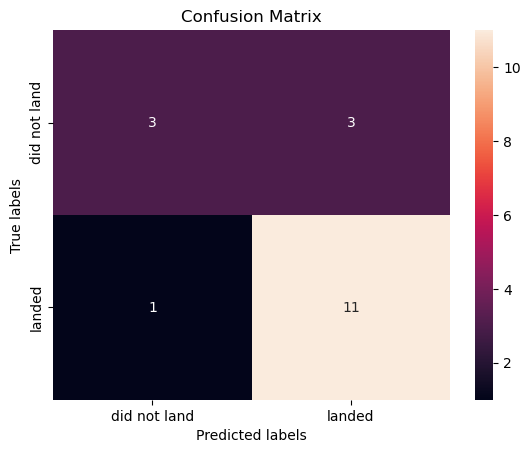

In [13]:
# Confusion matrix for logistic regression
yhat = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

### 4.2 Support Vector Machine (SVC)

In [14]:
# Pipeline: scale within CV folds + SVC
svm_pipe = Pipeline([
    ('scaler', preprocessing.StandardScaler()),
    ('model', SVC())
])

parameters = {
    'model__kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
    'model__C': np.logspace(-3, 3, 5),
    'model__gamma': np.logspace(-3, 3, 5)
}

In [15]:
svm_cv = GridSearchCV(svm_pipe, parameters, cv = 10)
svm_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...del', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': array([1.0000...00000000e+03]), 'model__gamma': array([1.0000...00000000e+03]), 'model__kernel': ('linear', ...)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and p

In [16]:
print('Tuned hyperparameters (best parameters): ', svm_cv.best_params_)
print('Accuracy: ', svm_cv.best_score_)

Tuned hyperparameters (best parameters):  {'model__C': np.float64(0.03162277660168379), 'model__gamma': np.float64(0.001), 'model__kernel': 'linear'}
Accuracy:  0.8642857142857144


In [17]:
# Evaluate SVC on the test split.
svm_accuracy = svm_cv.score(X_test, Y_test)
print('Accuracy on test data: ', svm_accuracy)

Accuracy on test data:  0.7777777777777778


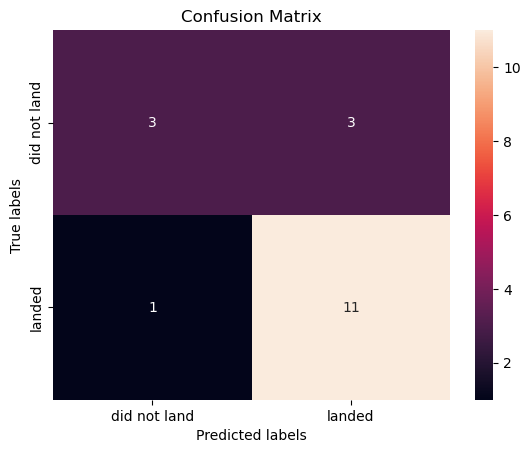

In [18]:
# Confusion matrix for SVC
yhat = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

### 4.3 Decision Tree

In [19]:
# Pipeline: no scaling needed for trees (passthrough)
tree_pipe = Pipeline([
    ('scaler', 'passthrough'),
    ('model', DecisionTreeClassifier(random_state = 2))
])

parameters = {
    'model__criterion': ['gini', 'entropy'],
    'model__splitter': ['best', 'random'],
    'model__max_depth': [2 * n for n in range(1, 10)],
    'model__max_features': ['sqrt', 'log2', None],
    'model__min_samples_leaf': [1, 2, 4],
    'model__min_samples_split': [2, 5, 10]
}

In [20]:
tree_cv = GridSearchCV(tree_pipe, parameters, cv = 10)
tree_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=2))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [2, 4, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the

In [21]:
print('Tuned hyperparameters (best parameters): ', tree_cv.best_params_)
print('Accuracy: ', tree_cv.best_score_)

Tuned hyperparameters (best parameters):  {'model__criterion': 'entropy', 'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__splitter': 'best'}
Accuracy:  0.8928571428571429


In [22]:
# Evaluate Decision Tree on the test split
tree_accuracy = tree_cv.score(X_test, Y_test)
print('Accuracy on test data: ', tree_accuracy)

Accuracy on test data:  0.6111111111111112


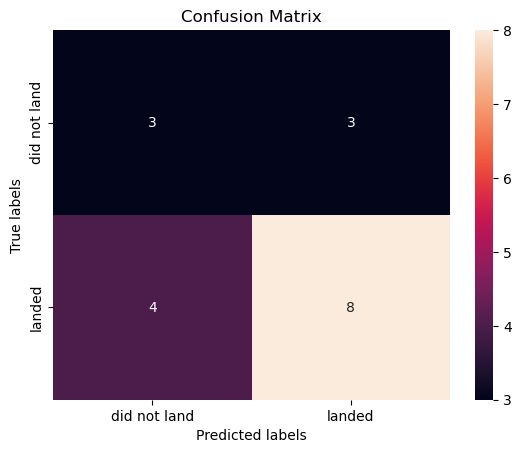

In [23]:
# Confusion matrix for Decision Tree
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

### 4.4 k-Nearest Neighbors (kNN)

In [24]:
# Pipeline: scale within CV folds + kNN
knn_pipe = Pipeline([
    ('scaler', preprocessing.StandardScaler()),
    ('model', KNeighborsClassifier())
])

parameters = {
    'model__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'model__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'model__p': [1, 2]
}

In [25]:
knn_cv = GridSearchCV(knn_pipe, parameters, cv = 10)
knn_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__algorithm': ['auto', 'ball_tree', ...], 'model__n_neighbors': [1, 2, ...], 'model__p': [1, 2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is dis

In [26]:
print('Tuned hyperparameters (best parameters): ', knn_cv.best_params_)
print('Accuracy: ', knn_cv.best_score_)

Tuned hyperparameters (best parameters):  {'model__algorithm': 'auto', 'model__n_neighbors': 4, 'model__p': 1}
Accuracy:  0.8625


In [27]:
# Evaluate KNN on the test split
knn_accuracy = knn_cv.score(X_test, Y_test)
print('Accuracy on test data: ', knn_accuracy)

Accuracy on test data:  0.7777777777777778


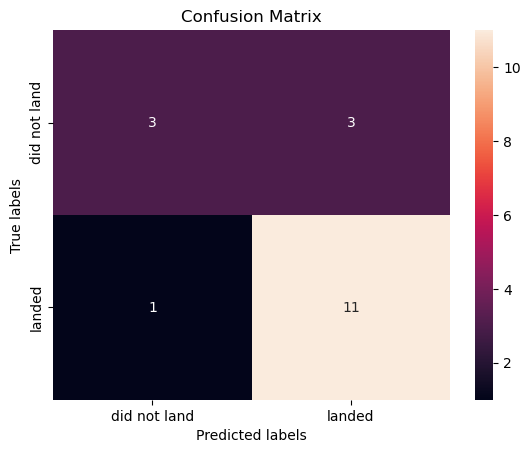

In [28]:
# Confusion matrix for KNN
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

## 5. Model comparison

We compare test accuracies. If multiple models tie, we break ties using the cross-validated training score from the grid search.

In [29]:
# Collect results in a single table
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Support Vector Machine',
        'Decision Tree',
        'K Nearest Neighbors'
    ],
    'Test Accuracy': [
        logreg_accuracy,
        svm_accuracy,
        tree_accuracy,
        knn_accuracy
    ],
    'CV Best Score': [
        logreg_cv.best_score_,
        svm_cv.best_score_,
        tree_cv.best_score_,
        knn_cv.best_score_
    ]
})

# Rank + pick best model (Test Accuracy first, then CV Best Score)
results = results.sort_values(
    by = ['Test Accuracy', 'CV Best Score'],
    ascending = False
).reset_index(drop = True)

best_model = results.iloc[0]['Model']
best_test_accuracy = results.iloc[0]['Test Accuracy']
best_cv = results.iloc[0]['CV Best Score']

# Mark ties on test accuracy
best_test_accuracy_model = results['Test Accuracy'].max()
results['Tied Best Test Accuracy'] = results['Test Accuracy'].eq(best_test_accuracy_model)

display(
    results.style
    .format({'Test Accuracy': '{:.4f}', 'CV Best Score': '{:.4f}'})
    .hide(axis = 'index')
)

print(f'Selected Best Model: {best_model}')
print(f'Test accuracy: {best_test_accuracy:.4f} | CV Best Score: {best_cv:.4f}')

Model,Test Accuracy,CV Best Score,Tied Best Test Accuracy
Support Vector Machine,0.7778,0.8643,True
K Nearest Neighbors,0.7778,0.8625,True
Logistic Regression,0.7778,0.8518,True
Decision Tree,0.6111,0.8929,False


Selected Best Model: Support Vector Machine
Test accuracy: 0.7778 | CV Best Score: 0.8643


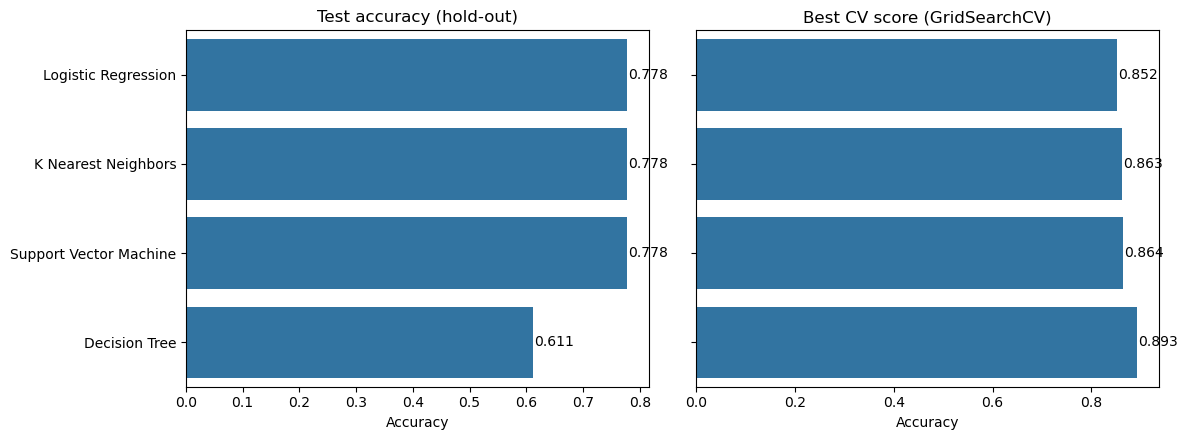

In [30]:
# Visualize model performance
plot_df = results[['Model', 'Test Accuracy', 'CV Best Score']].copy()
plot_df = plot_df.sort_values('Test Accuracy', ascending = True)
fig, axes = plt.subplots(1, 2, figsize = (12, 4.5), sharey = True)

# Left: Test Accuracy
sns.barplot(data = plot_df, x = 'Test Accuracy', y = 'Model', ax = axes[0])
axes[0].set_title('Test accuracy (hold-out)')
axes[0].set_xlabel('Accuracy')
axes[0].set_ylabel('')

# Right: CV Best Score
sns.barplot(data = plot_df, x = 'CV Best Score', y = 'Model', ax = axes[1])
axes[1].set_title('Best CV score (GridSearchCV)')
axes[1].set_xlabel('Accuracy')
axes[1].set_ylabel('')

# Make the best appear on top (since we sorted ascending)
axes[0].invert_yaxis()

for ax, col in zip(axes, ['Test Accuracy', 'CV Best Score']):
    for p in ax.patches:
        val = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.text(val + 0.002, y, f'{val:.3f}', va = 'center')

plt.tight_layout()
plt.show()    

## 6. Export artifacts

To make this final notebook easy to review and reproduce, we export a small set of artifacts that summarize results and enable re-use without re-running the full training pipeline.

**Artifacts written to `../data/processed/`:**
- `08_model_performance.csv`: compact comparison table (test accuracy, best CV score, best params)
- `08_best_model.json`: 'model card' with the selected best model + metadata (split seed, CV folds, library versions)
- `08_best_model.joblib`: serialized fitted pipeline (**StandardScaler + best estimator**) for later inference
- `08_feature_names.json`: ordered feature names expected by the pipeline (from `05_dataset_part_3.csv`)

In [31]:
# Export performance table + model card (JSON) + serialized best model (joblib)
from datetime import datetime, timezone
import sys

import sklearn
from joblib import dump

# Map model names to their GridSearchCV objects
cv_objects = {
    'Logistic Regression': logreg_cv,
    'Support Vector Machine': svm_cv,
    'Decision Tree': tree_cv,
    'K Nearest Neighbors': knn_cv
}

# Performance summary (CSV)
param_map = {name: cv.best_params_ for name, cv in cv_objects.items()}

model_perf = results[['Model', 'Test Accuracy', 'CV Best Score']].copy()
model_perf['Best Params'] = model_perf['Model'].map(param_map)

# Save a CSV of model performance
model_perf_csv = model_perf.copy()
model_perf_csv['Best Params'] = model_perf_csv['Best Params'].apply(
    lambda d: json.dumps(d, ensure_ascii = False, sort_keys = True)
)
model_perf_csv.to_csv(MODEL_PERF_OUT, index = False)

display(
    model_perf.style
    .format({'Test Accuracy': '{:.4f}', 'CV Best Score': '{:.4f}'})
    .hide(axis = 'index')
)

# Feature names (JSON)
FEATURE_NAMES_OUT = PROCESSED_DIR / '08_feature_names.json'
feature_names = pd.read_csv(DATASET_PART_3, nrows = 0).columns.tolist()
FEATURE_NAMES_OUT.write_text(
    json.dumps(feature_names, indent = 2, ensure_ascii = False),
    encoding = 'utf-8'
)

# Serialized best model (joblib)
MODEL_JOBLIB_OUT = PROCESSED_DIR / '08_best_model.joblib'

best_cv_obj = cv_objects[best_model]
best_estimator = best_cv_obj.best_estimator_

# All GridSearchCV objects are defined on pipelines, so best_estimator is already fitted and self-contained.
dump(
    {'pipeline': best_estimator, 'feature_names': feature_names},
    MODEL_JOBLIB_OUT
)

# Model card (JSON)
best_payload = {
    'selected_best_model': best_model,
    'test_accuracy': float(best_test_accuracy),
    'cv_best_score': float(best_cv),
    'best_params': best_cv_obj.best_params_,
    'pipeline_steps': list(best_estimator.named_steps.keys()) if hasattr(best_estimator, 'named_steps') else None,
    'split': {
        'test_size': 0.2,
        'random_state': 2,
        'stratify': True
    },
    'validation': {
        'cv_folds': 10
    },
    'inputs': {
        'dataset_part_2': DATASET_PART_2.as_posix(),
        'dataset_part_3': DATASET_PART_3.as_posix()
    },
    'outputs': {
        'model_performance_csv': MODEL_PERF_OUT.as_posix(),
        'best_model_json': BEST_MODEL_OUT.as_posix(),
        'best_model_joblib': MODEL_JOBLIB_OUT.as_posix(),
        'feature_names_json': FEATURE_NAMES_OUT.as_posix()
    },
    'environment': {
        'python': sys.version.split()[0],
        'sklearn': sklearn.__version__,
        'numpy': np.__version__,
        'pandas': pd.__version__
    },
    'created_utc': datetime.now(timezone.utc).isoformat()
}

BEST_MODEL_OUT.write_text(
    json.dumps(best_payload, indent = 2, ensure_ascii = False),
    encoding = 'utf-8'
)

Model,Test Accuracy,CV Best Score,Best Params
Support Vector Machine,0.7778,0.8643,"{'model__C': np.float64(0.03162277660168379), 'model__gamma': np.float64(0.001), 'model__kernel': 'linear'}"
K Nearest Neighbors,0.7778,0.8625,"{'model__algorithm': 'auto', 'model__n_neighbors': 4, 'model__p': 1}"
Logistic Regression,0.7778,0.8518,"{'model__C': 1, 'model__solver': 'lbfgs'}"
Decision Tree,0.6111,0.8929,"{'model__criterion': 'entropy', 'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__splitter': 'best'}"


1038

## 7. Assumptions
- The target `Class` correctly represents first-stage landing success (1) vs not (0) as engineered in Step 03.
- The feature matrix from Step 05 contains only information available at/before launch; no post-outcome leakage is intentionally included.
- The 80/20 split (random_state = 2) is treated as representative; this is not a time-based split and may overestimate performance if launch conditions drift over time.
- Accuracy is used as the primary metric (equal cost of false positives/false negatives).
- Cross-validation assumes samples are independent (no grouping by launch site, year, or booster category).

---